In [2]:
import pandas as pd
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk as nltk

# RELISH data analysis

In [14]:
RESLISH_Data_PATH = "../data/Input/RELISH/TSV/sample.tsv"

relish_data = pd.read_csv(RESLISH_Data_PATH, sep='\t')
relish_data.head()

,PMID,title,abstract
0,29537078,Investigating global trends in paraquat intoxi...,BACKGROUND: Paraquat is considered to be the m...
1,20356685,Pathological research output in China and othe...,The present study was designed to study the re...
2,21836696,Indian research on disaster and mental health.,The primary source for this annotation on disa...
3,24719495,Trends in and contributions to entrepreneurshi...,"This article, which began as an effort to gaug..."
4,25987099,Innovation status of gene therapy for breast c...,BACKGROUND: To analyze multi-source data inclu...


In [3]:
print("Given dataset shape is: {}".format(relish_data.shape))
print("Given dataset columns are: {}".format(relish_data.columns))
print("Total number of PMIDs in RELISH:",relish_data["PMID"].value_counts().shape[0])
print("Total number of unique PMIDs in RELISH:",relish_data["PMID"].nunique())
print("Total number of empty PMIDs in RELISH:",relish_data["PMID"].isnull().sum())
print("Range of PMIDs in RELISH:",relish_data["PMID"].min(),relish_data["PMID"].max())

Given dataset shape is: (163190, 3)
Given dataset columns are: Index(['PMID', 'title', 'abstract'], dtype='object')
Total number of PMIDs in RELISH: 163190
Total number of unique PMIDs in RELISH: 163190
Total number of empty PMIDs in RELISH: 0
Range of PMIDs in RELISH: 1424236 29990624


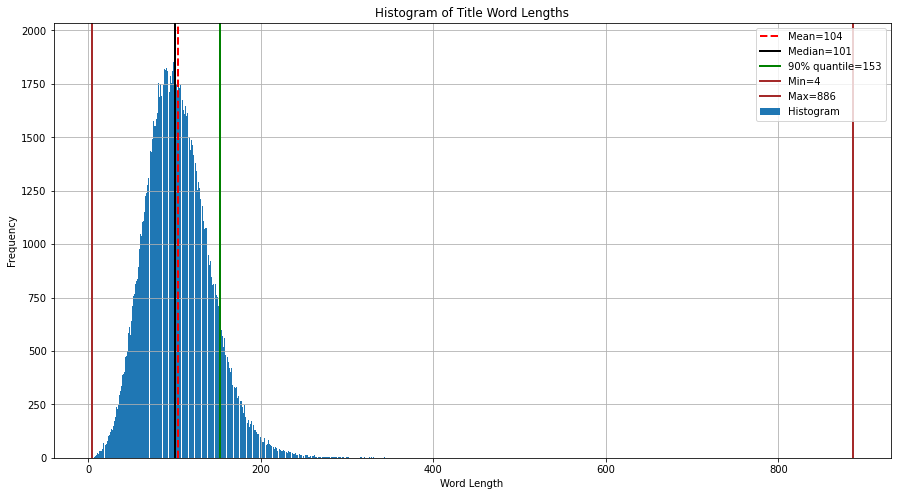

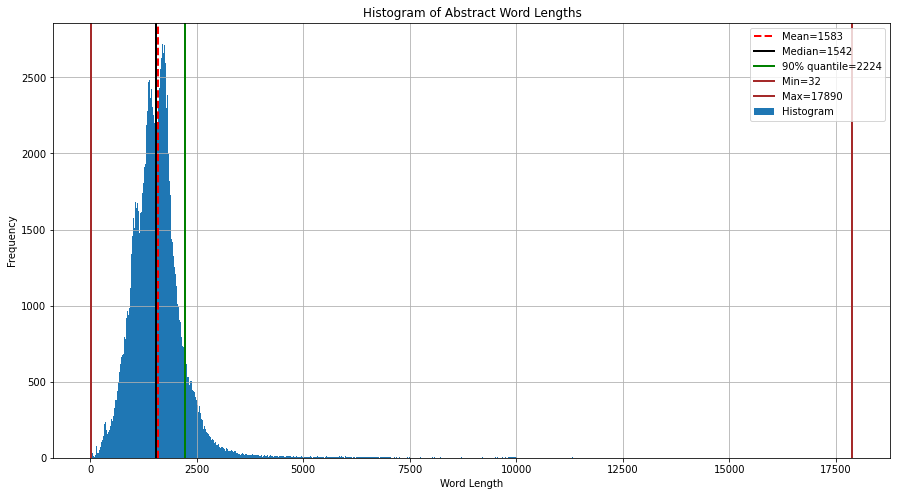

In [4]:
title_word_lens = relish_data["title"].str.len()
mean=round(np.mean(title_word_lens))
median = round(np.median(title_word_lens))
quantile = round(np.quantile(title_word_lens,0.90))
min_ = round(np.min(title_word_lens))
max_ = round(np.max(title_word_lens))
plt.figure(figsize=(15,8))
plt.hist(title_word_lens, bins=1000)
plt.axvline(x=mean, color='r', linestyle='dashed', linewidth=2)
plt.axvline(x=median, color='black', linewidth=2)
plt.axvline(x=quantile, color='g', linewidth=2)
plt.axvline(x=max_, color='brown', linewidth=2)
plt.axvline(x=min_, color='brown', linewidth=2)
plt.title("Histogram of Title Word Lengths")
plt.xlabel("Word Length")
plt.ylabel("Frequency")
plt.legend(['Mean='+str(mean),'Median='+str(median),'90% quantile='+str(quantile),
            'Min='+str(min_),'Max='+str(max_),'Histogram'], loc='upper right')
plt.grid()
plt.show()

abstract_word_lens = relish_data["abstract"].str.len()
mean = round(np.mean(abstract_word_lens))
median = round(np.median(abstract_word_lens))
quantile = round(np.quantile(abstract_word_lens,0.90))
min_ = round(np.min(abstract_word_lens))
max_ = round(np.max(abstract_word_lens))
plt.figure(figsize=(15,8))
plt.hist(abstract_word_lens, bins=1000)
plt.axvline(x=mean, color='r', linestyle='dashed', linewidth=2)
plt.axvline(x=median, color='black', linewidth=2)
plt.axvline(x=quantile, color='g', linewidth=2)
plt.axvline(x=min_, color='brown', linewidth=2)
plt.axvline(x=max_, color='brown', linewidth=2)
plt.title("Histogram of Abstract Word Lengths")
plt.xlabel("Word Length")
plt.ylabel("Frequency")
plt.legend(['Mean='+str(mean),'Median='+str(median),'90% quantile='+str(quantile),
            'Min='+str(min_),'Max='+str(max_),'Histogram'], loc='upper right')
plt.grid()
plt.show()

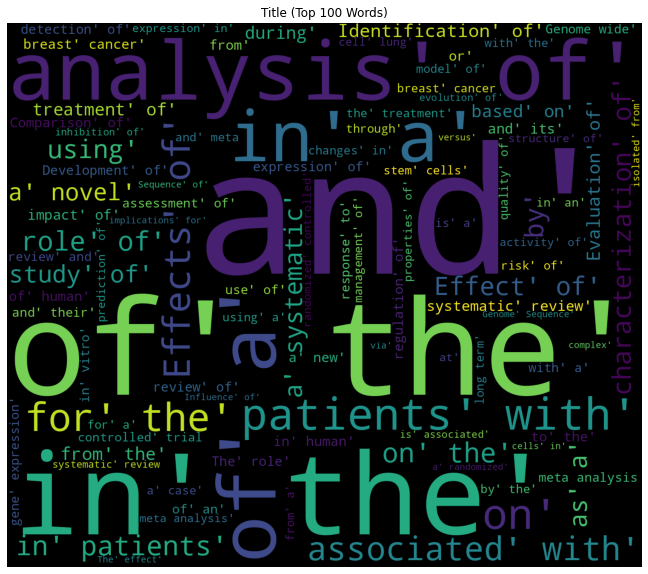

In [7]:
# list of unique words in titles
title_words = relish_data["title"].str.split(" ").apply(pd.Series, "keyword").stack().tolist()

def generate_wordcloud(data,title=""):
    plt.subplots(figsize=(16,10))
    wordcloud = WordCloud(
                            background_color='black',
                            max_words=100,
                            width=1400,
                            height=1200
                            ).generate(str(title_words))
    plt.imshow(wordcloud)
    plt.title(title+" "+'(Top 100 Words)')
    plt.axis('off')
    plt.show()

generate_wordcloud(title_words,title="Title")

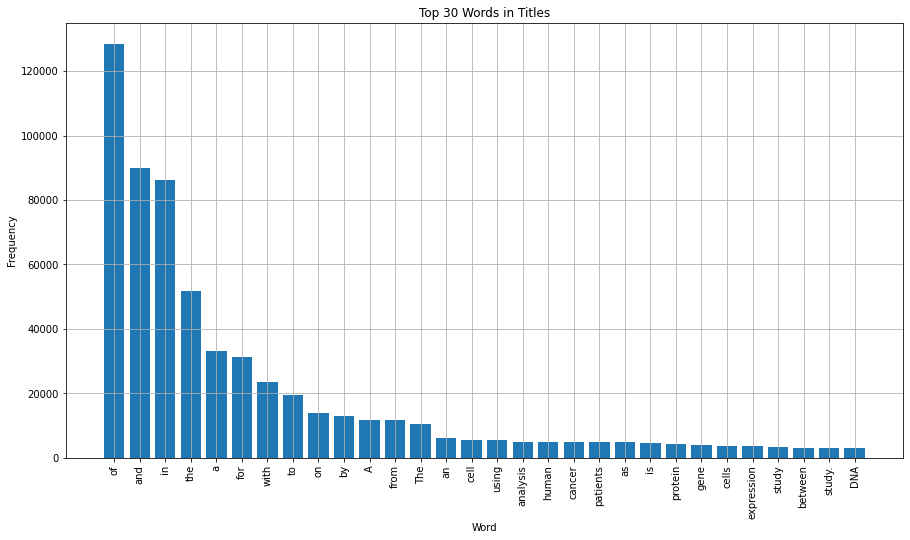

In [12]:
counter = nltk.FreqDist(title_words)
top_30_words = counter.most_common(30)
plt.figure(figsize=(15,8))
plt.bar(range(len(top_30_words)), [i[1] for i in top_30_words], align='center')
plt.xticks(range(len(top_30_words)), [i[0] for i in top_30_words], rotation=90)
plt.title("Top 30 Words in Titles")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.grid()
plt.show()

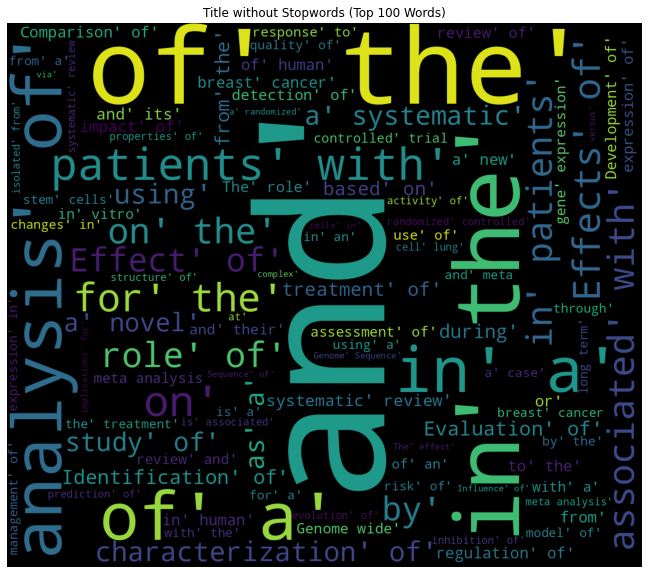

In [13]:
# remove stopwords from titles
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
title_words_no_stopwords = [word for word in title_words if word not in stop_words]
# plot wordcloud of titles without stopwords
generate_wordcloud(title_words_no_stopwords,title="Title without Stopwords")


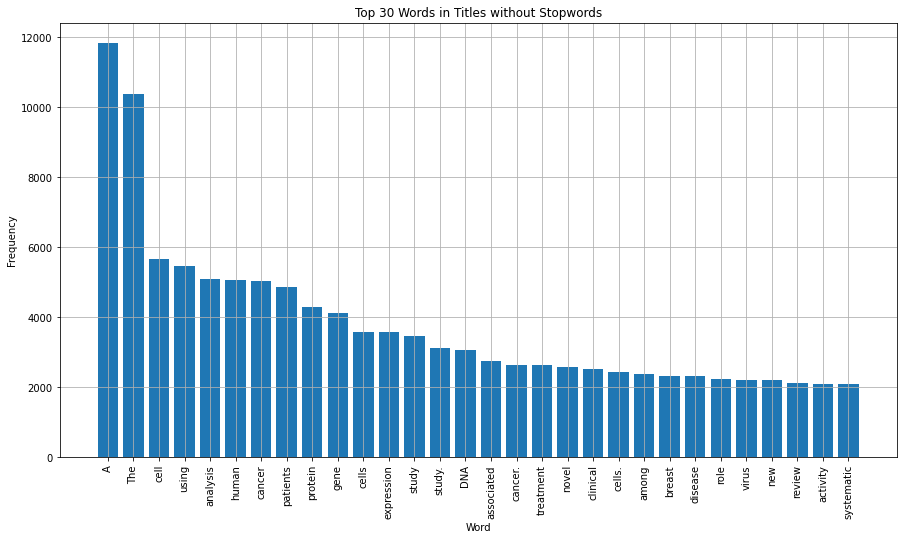

In [14]:
# plot top 30 words in titles without stopwords
counter = nltk.FreqDist(title_words_no_stopwords)
top_30_words = counter.most_common(30)
plt.figure(figsize=(15,8))
plt.bar(range(len(top_30_words)), [i[1] for i in top_30_words], align='center')
plt.xticks(range(len(top_30_words)), [i[0] for i in top_30_words], rotation=90)
plt.title("Top 30 Words in Titles without Stopwords")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [24]:
# remove special characters but keep numbers
import re
title_words = [re.sub('[^A-Za-z0-9]+', '', word) for word in title_words_no_stopwords]

# find acronyms in titles
acronyms = []
for word in title_words:
    if word.isupper():
        acronyms.append(word)

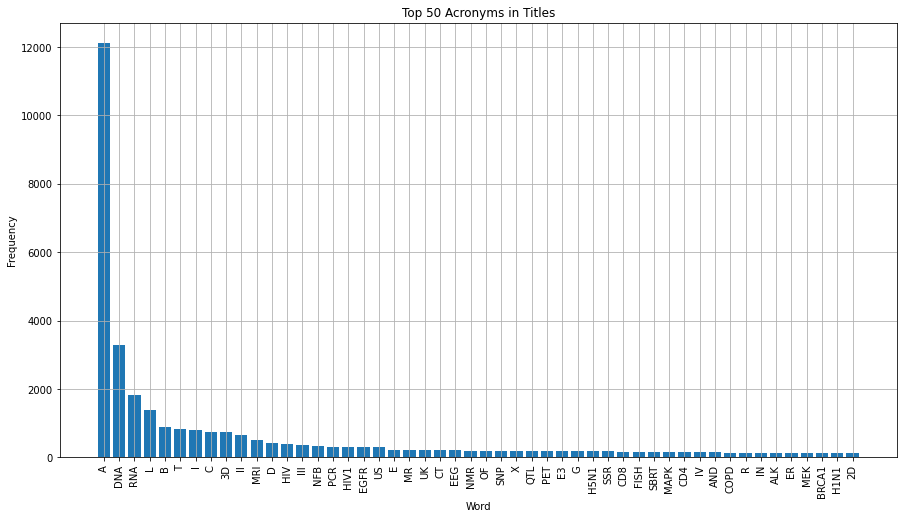

In [23]:
# plot top 30 words in acronyms
counter = nltk.FreqDist(acronyms)
top_50_words = counter.most_common(50)
plt.figure(figsize=(15,8))
plt.bar(range(len(top_50_words)), [i[1] for i in top_50_words], align='center')
plt.xticks(range(len(top_50_words)), [i[0] for i in top_50_words], rotation=90)
plt.title("Top 50 Acronyms in Titles")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.grid()
plt.show()


## TREC data analysis

In [25]:
TREC_DATA_PATH = "../CORPORA/TREC/TREC_documents.tsv"

In [26]:
trec_data = pd.read_csv(TREC_DATA_PATH, sep='\t')
trec_data.head()

,PMID,title,abstract
0,9102202,Distinct somatic genetic changes associated wi...,BRCA1 and BRCA2 mutations confer increased ris...
1,9105560,Familial ligand-defective apolipoprotein B-100...,Familial ligand-defective apolipoprotein (apo)...
2,9112375,Overexpression and activation of the insulin r...,"In this study, a partial hamster complementary..."
3,9112401,Up-regulation of insulin/insulin-like growth f...,To assess the autocrine function of insulin-li...
4,9120013,RNA metabolism in myotonic dystrophy: patient ...,Myotonic dystrophy is a dominantly inherited c...


In [27]:
print("Given dataset shape is: {}".format(trec_data.shape))
print("Given dataset columns are: {}".format(trec_data.columns))
print("Total number of PMIDs in TREC:",trec_data["PMID"].value_counts().shape[0])
print("Total number of unique PMIDs in TREC:",trec_data["PMID"].nunique())
print("Total number of empty PMIDs in TREC:",trec_data["PMID"].isnull().sum())
print("Range of PMIDs in TREC:",trec_data["PMID"].min(),trec_data["PMID"].max())

Given dataset shape is: (32605, 3)
Given dataset columns are: Index(['PMID', 'title', 'abstract'], dtype='object')
Total number of PMIDs in TREC: 32605
Total number of unique PMIDs in TREC: 32605
Total number of empty PMIDs in TREC: 0
Range of PMIDs in TREC: 95800 14669790


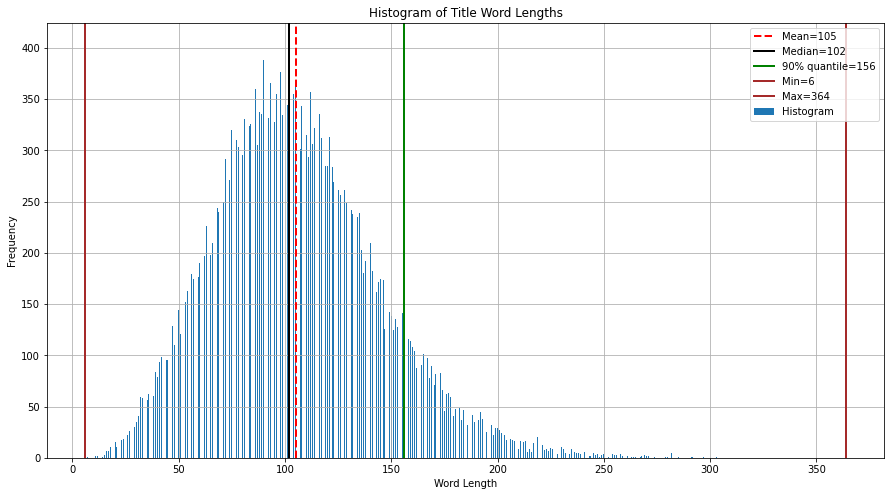

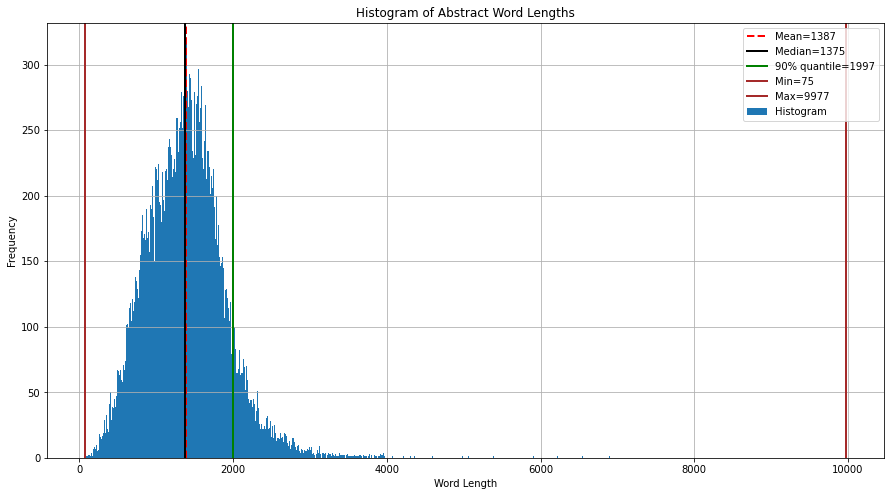

In [28]:
title_word_lens = trec_data["title"].str.len()
mean=round(np.mean(title_word_lens))
median = round(np.median(title_word_lens))
quantile = round(np.quantile(title_word_lens,0.90))
min_ = round(np.min(title_word_lens))
max_ = round(np.max(title_word_lens))
plt.figure(figsize=(15,8))
plt.hist(title_word_lens, bins=1000)
plt.axvline(x=mean, color='r', linestyle='dashed', linewidth=2)
plt.axvline(x=median, color='black', linewidth=2)
plt.axvline(x=quantile, color='g', linewidth=2)
plt.axvline(x=max_, color='brown', linewidth=2)
plt.axvline(x=min_, color='brown', linewidth=2)
plt.title("Histogram of Title Word Lengths")
plt.xlabel("Word Length")
plt.ylabel("Frequency")
plt.legend(['Mean='+str(mean),'Median='+str(median),'90% quantile='+str(quantile),
            'Min='+str(min_),'Max='+str(max_),'Histogram'], loc='upper right')
plt.grid()
plt.show()

abstract_word_lens = trec_data["abstract"].str.len()
mean = round(np.mean(abstract_word_lens))
median = round(np.median(abstract_word_lens))
quantile = round(np.quantile(abstract_word_lens,0.90))
min_ = round(np.min(abstract_word_lens))
max_ = round(np.max(abstract_word_lens))
plt.figure(figsize=(15,8))
plt.hist(abstract_word_lens, bins=1000)
plt.axvline(x=mean, color='r', linestyle='dashed', linewidth=2)
plt.axvline(x=median, color='black', linewidth=2)
plt.axvline(x=quantile, color='g', linewidth=2)
plt.axvline(x=min_, color='brown', linewidth=2)
plt.axvline(x=max_, color='brown', linewidth=2)
plt.title("Histogram of Abstract Word Lengths")
plt.xlabel("Word Length")
plt.ylabel("Frequency")
plt.legend(['Mean='+str(mean),'Median='+str(median),'90% quantile='+str(quantile),
            'Min='+str(min_),'Max='+str(max_),'Histogram'], loc='upper right')
plt.grid()
plt.show()

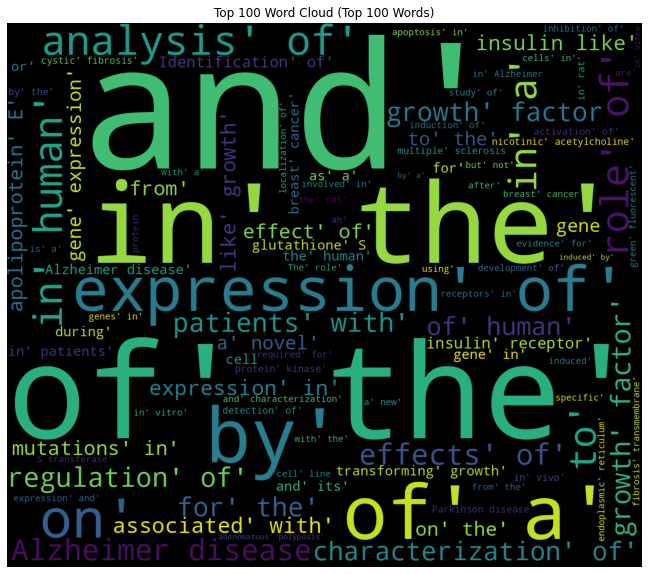

In [29]:
# list of unique words in titles
title_words = trec_data["title"].str.split(" ").apply(pd.Series, "keyword").stack().tolist()

generate_wordcloud(title_words,title="Top 100 Word Cloud")

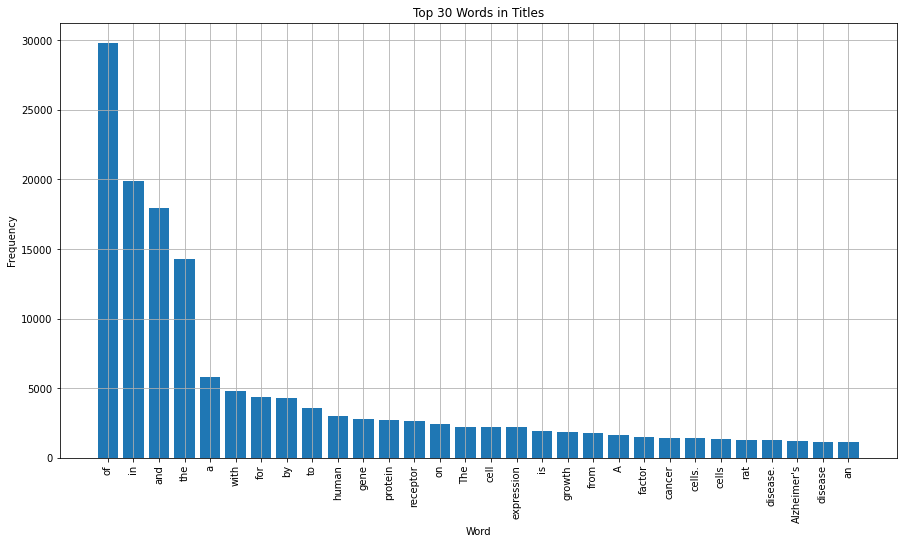

In [30]:
counter = nltk.FreqDist(title_words)
top_30_words = counter.most_common(30)
plt.figure(figsize=(15,8))
plt.bar(range(len(top_30_words)), [i[1] for i in top_30_words], align='center')
plt.xticks(range(len(top_30_words)), [i[0] for i in top_30_words], rotation=90)
plt.title("Top 30 Words in Titles")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.grid()
plt.show()

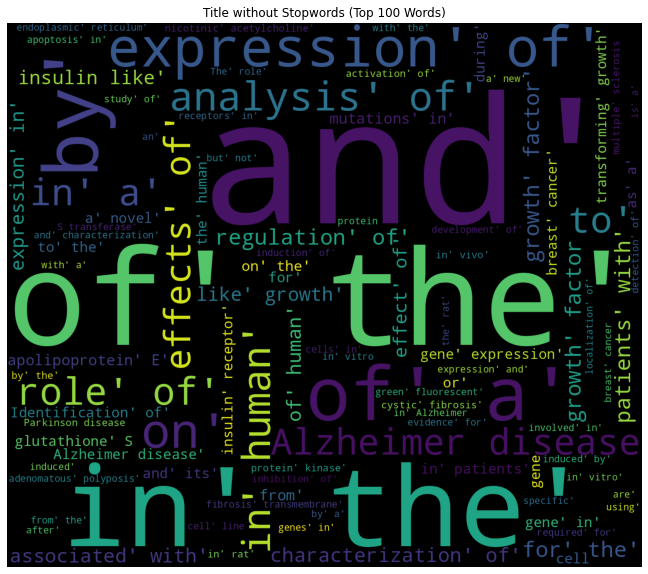

In [31]:
title_words_no_stopwords = [word for word in title_words if word not in stop_words]
# plot wordcloud of titles without stopwords
generate_wordcloud(title_words_no_stopwords,title="Title without Stopwords")

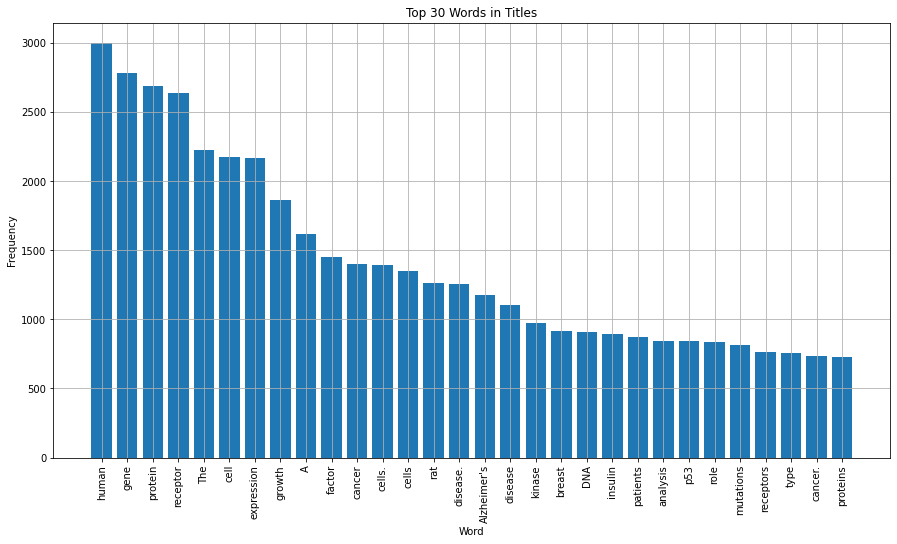

In [33]:
counter = nltk.FreqDist(title_words_no_stopwords)
top_30_words = counter.most_common(30)
plt.figure(figsize=(15,8))
plt.bar(range(len(top_30_words)), [i[1] for i in top_30_words], align='center')
plt.xticks(range(len(top_30_words)), [i[0] for i in top_30_words], rotation=90)
plt.title("Top 30 Words in Titles")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.grid()
plt.show()

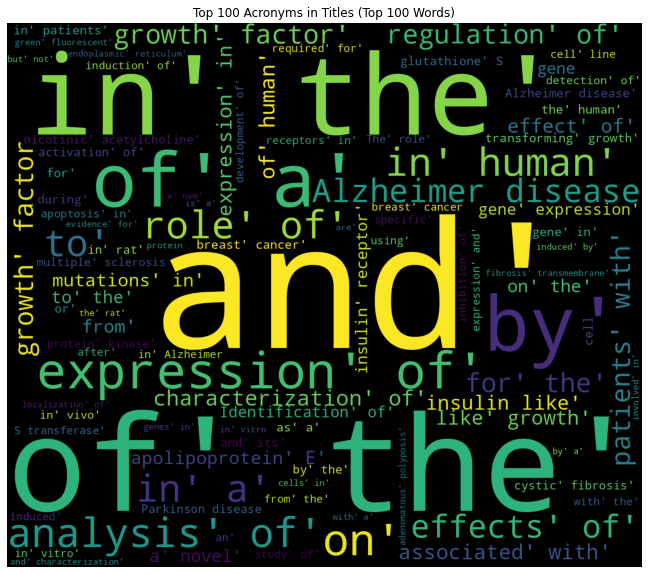

In [34]:
acronyms = []
for word in title_words_no_stopwords:
    if word.isupper():
        acronyms.append(word)
        
        
generate_wordcloud(acronyms,title="Top 100 Acronyms in Titles")

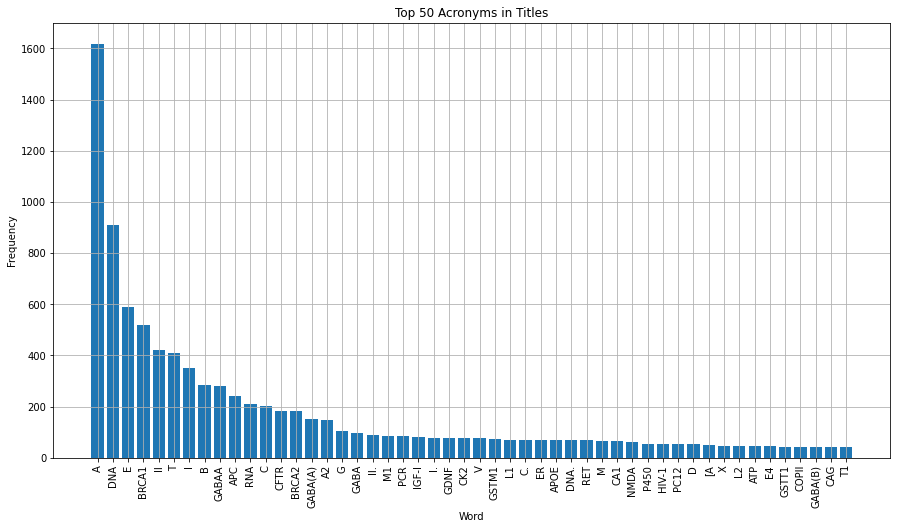

In [35]:
# plot top 30 words in acronyms
counter = nltk.FreqDist(acronyms)
top_50_words = counter.most_common(50)
plt.figure(figsize=(15,8))
plt.bar(range(len(top_50_words)), [i[1] for i in top_50_words], align='center')
plt.xticks(range(len(top_50_words)), [i[0] for i in top_50_words], rotation=90)
plt.title("Top 50 Acronyms in Titles")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.grid()
plt.show()